In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

# Ensure modules are reloaded on any change (very useful when developing code on the fly)
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import seaborn as sns
from programmable_cubes_UDP import ProgrammableCubes
from programmable_cubes_UDP import programmable_cubes_UDP
import numpy as np
from pygmo import problem
import random
from implementation_heuristic import *

## Combination of algorithms to achieve best result


- create udp
- create chromosome
- use find chromosome to apply the method with some parameters
- !!! always call the fitness afterwards to update the cube ensemble

In [3]:
PROBLEM = "ISS_INV"
udp = programmable_cubes_UDP(PROBLEM)
udp.fitness(np.array([-1]))
ti = udp.initial_cube_types
ci = udp.final_cube_positions
ct = udp.target_cube_positions
tt = udp.target_cube_types
types = np.arange(np.max(ti)+1)



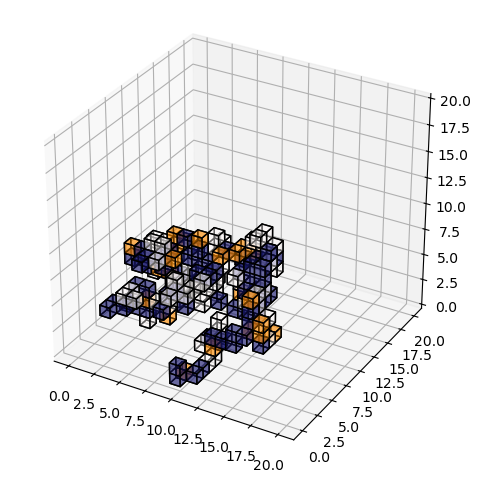

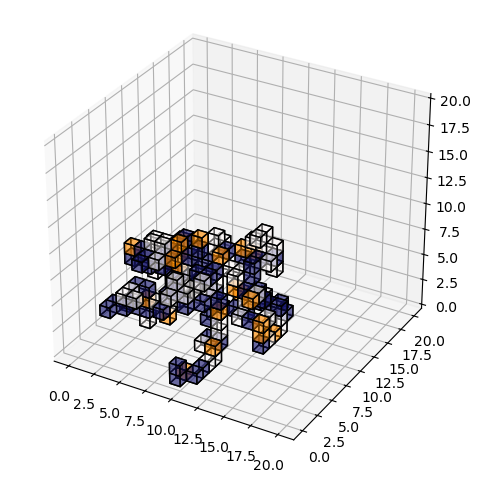

(54, 3)
(54,)


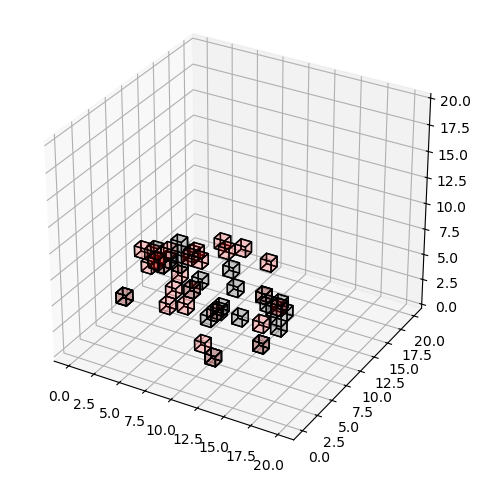

In [29]:
def debug_plot(udp:programmable_cubes_UDP):
    ti = udp.initial_cube_types
    ci = udp.final_cube_positions
    ct = udp.target_cube_positions
    tt = udp.target_cube_types
    wti = have_wrong_type(ci,ti,ct,tt)
    # wti - wrong type ids, from cube_position
    # These are cubes away from the structure and the hollow points in the structure
    wpi, epi = get_wrong_cube_ids(ci,ct)
    if len(wti) == 0:
        wti = np.array([], dtype=int)
    if len(epi) == 0:
        epi = np.array([], dtype=int)
    if len(wpi) == 0:
        wpi = np.array([], dtype=int)
    # wpi - wrong place ids, from cube_position
    # epi - empty place ids, from target configuration ct

    wrong_ids_initial = np.concatenate([wti,wpi])
    coordinates_initial = np.concatenate([ct[wti],ct[wpi]])
    debug_types_initial = -np.ones(shape=(coordinates_initial.shape[0]),dtype=int)
    wrong_ids_target = np.concatenate([wti,epi])
    coordinates_target = np.concatenate([ct[epi],ct[wti]])
    debug_types_target = -2*np.ones(shape=(coordinates_target.shape[0]),dtype=int)
    all_coords =np.concatenate([coordinates_initial,coordinates_target])
    all_types = np.concatenate([debug_types_initial,debug_types_target])
    print(all_coords.shape)
    print(all_types.shape)
    np.save(f"out_wrong",all_coords)

    udp.debug_plot("none",cube_type_to_plot=types,custom_config=all_coords,custom_cube_types=all_types)

udp.plot('ensemble',types)
udp.plot('target',types)
debug_plot(udp)


In [4]:

def apply_find_chromosome_multiple_times(udp:programmable_cubes_UDP,method=find_chromosome,count=1,chromosome = np.array([]),random_shuffle = False):
    """ 
    udp has to be initialized
    """
    for i in range(count):
        tmp_chrom = method(udp,random_shuffle)
        chromosome = np.concatenate([chromosome,tmp_chrom])
        print(udp.fitness(np.concatenate([tmp_chrom,np.array([-1])]),udp.final_cube_positions))
    return chromosome

[np.float64(-0.0)]
mistakes:104+22 budget status: 6.232813932172319 % used, successes: 82
[np.float64(-0.6426584362139919)]
mistakes:37+7 budget status: 2.8497625197900174 % used, successes: 24
[np.float64(-0.8375502645502647)]
mistakes:16+4 budget status: 0.7332722273143905 % used, successes: 3
[np.float64(-0.86412228101117)]
mistakes:14+3 budget status: 0.6166152820598283 % used, successes: 2
[np.float64(-0.8801475602586715)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
[np.float64(-0.8673356848912405)]
mistak

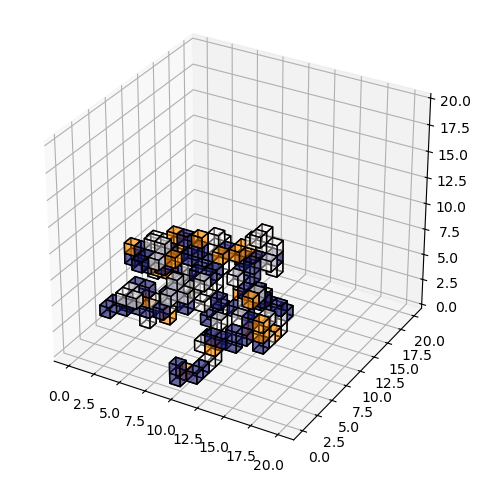

mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
mistakes:12+3 budget status: 0.0 % used, successes: 0
[np.float64(-0.8809523809523809)]
[np.float64(-0.8673356848912405)]


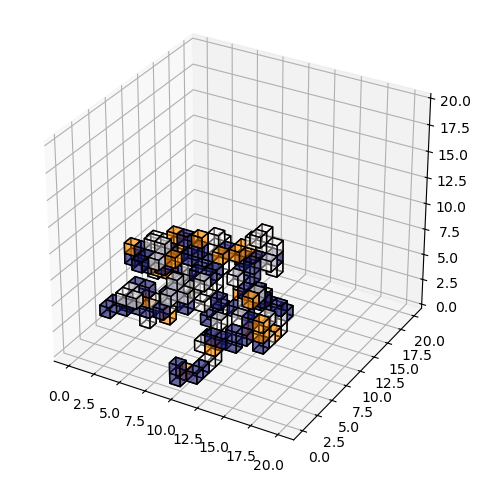

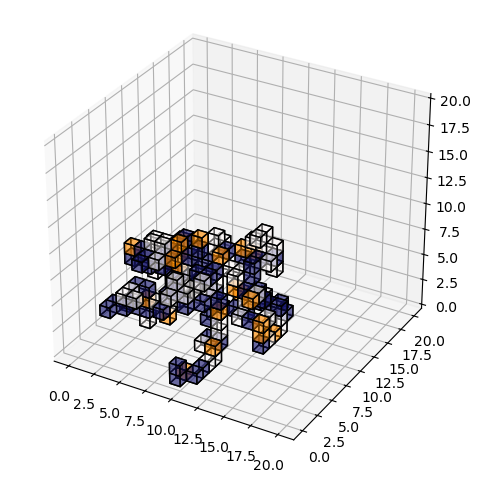

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
def find_chromosome_heuristic(udp:programmable_cubes_UDP, random_shuffle = False):
    """ 
    Idea:
    mark indices at wrong places and with wrong types only once
    try to move the closest
    extend to further apart
    
    """
    # Initialize cubes
    cubes = ProgrammableCubes(udp.final_cube_positions)
    ti = udp.initial_cube_types
    ci = udp.final_cube_positions
    ct = udp.target_cube_positions
    tt = udp.target_cube_types
    types = np.arange(np.max(ti)+1)

    # Initialize outputs
    chrom = []
    iter = 0
    successes = 0

    # These are part of the structure but with wrong type => need to be moved to allow others move in
    wti = have_wrong_type(cubes.cube_position,ti,ct,tt)
    # wti - wrong type ids, from cube_position
    # These are cubes away from the structure and the hollow points in the structure
    wpi, epi = get_wrong_cube_ids(cubes.cube_position,ct)

    empty_coords = ct[epi]
    empty_coords_types = tt[epi]
    # wpi - wrong place ids, from cube_position
    # epi - empty place ids, from target configuration ct

    if len(wti) == 0:
        wti = np.array([], dtype=int)
    if len(epi) == 0:
        epi = np.array([], dtype=int)
    if len(wpi) == 0:
        wpi = np.array([], dtype=int)

    if random_shuffle:
        for id in range(len(ti)):
            move = force_random_move(id,cubes,id)
            if move != -1:
                chrom.extend([id,move])

    # Step 1: move wti to epi
    for id in wti:
        empty_coords_with_correct_type = empty_coords[empty_coords_types==ti[id]]

        start = np.array(cubes.cube_position[id])
        tmp_chrom, tmp_path, success = dijkstra_cubes_multiple(cubes,id,empty_coords_with_correct_type)
        if success:
            chrom.extend(tmp_chrom)
            cubes.apply_chromosome(np.concatenate([tmp_chrom,[-1]]),True)
            end = tmp_path[tmp_path.shape[0]-1]
            end_id = contains_coord(empty_coords,end)
            empty_coords = np.delete(empty_coords,end_id,0)
            empty_coords_types = np.delete(empty_coords_types,end_id,0)
            successes += 1

    # Step 2: move move wpi to epi (TODO or wti)
    for id in wpi:
        empty_coords_with_correct_type = empty_coords[empty_coords_types==ti[id]]

        start = np.array(cubes.cube_position[id])
        tmp_chrom, tmp_path, success = dijkstra_cubes_multiple(cubes,id,empty_coords_with_correct_type)
        if success:
            chrom.extend(tmp_chrom)
            cubes.apply_chromosome(np.concatenate([tmp_chrom,[-1]]),True)
            end = tmp_path[tmp_path.shape[0]-1]
            end_id = contains_coord(empty_coords,end)
            empty_coords = np.delete(empty_coords,end_id,0)
            empty_coords_types = np.delete(empty_coords_types,end_id,0)
            successes += 1
    

    

    print(f"mistakes:{len(wpi)}+{len(wti)} budget status: {len(chrom)/udp.get_nix()*100} % used, successes: {successes}")
    return np.array(chrom,dtype=int)
print(udp.fitness(np.array([-1])))
chrom = apply_find_chromosome_multiple_times(udp,find_chromosome_heuristic,10)
print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
chrom = np.concatenate([chrom,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
udp.plot('ensemble', types)
chrom = apply_find_chromosome_multiple_times(udp,find_chromosome_heuristic,10,chrom,False)
print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
udp.plot('ensemble', types)
udp.plot('target', types)
# chrom = np.concatenate([chrom,find_chromosome(udp,pair_colours,axis_search_always_move)])
# print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
# udp.plot('ensemble', types)
# chrom = apply_find_chromosome_multiple_times(udp,find_chromosome_heuristic,2,chrom)
# print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
# udp.plot('ensemble', types)
#chrom = find_chromosome_heuristic(udp)
#print(chrom)
#chrom = format_chromosome(udp,chrom)




[ 18.   3.  18. ...   2. 108.   0.] [130   1 130 ...   0  63   2]
[np.float64(-0.12141563786008225)]


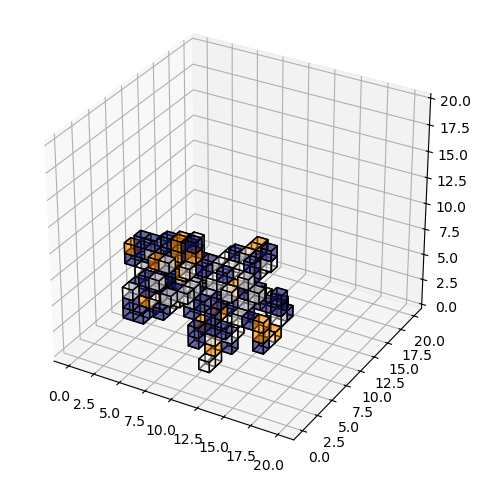

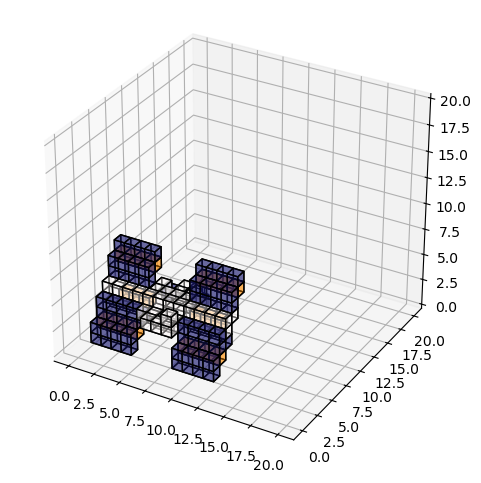

In [6]:
# Check if invesion works on original udp
PROBLEM2 = "ISS"
udp2 = programmable_cubes_UDP(PROBLEM2)
inv_chrom = invert_chromosome(udp,chrom)
print(chrom,inv_chrom)
print(udp2.fitness(format_chromosome(udp2,inv_chrom)))
udp2.plot('ensemble',types)
udp2.plot('target',types)

In [7]:
print(udp.fitness(end_chromosome(chrom)))

[np.float64(-0.8673356848912405)]


In [ ]:
chromosome = find_chromosome(udp,pair_colours,axis_search)
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,astar_cubes)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)

udp.fitness(np.array([-1]))
chromosome = format_chromosome(udp,chromosome)
print(udp.fitness(chromosome))

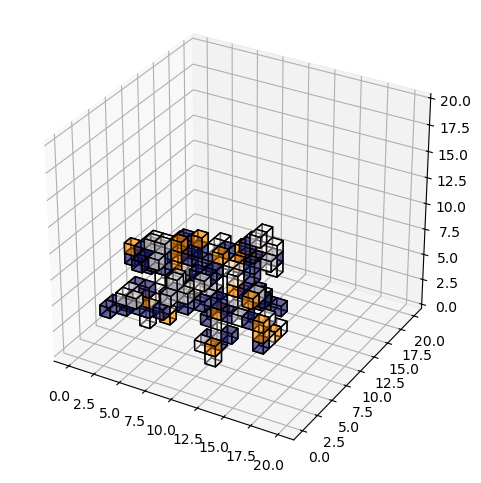

In [9]:
np.save("chromosome_jwst",chrom)
udp.plot('ensemble', types)

In [28]:
def save_setup_in_time(udp:programmable_cubes_UDP,chromosome:np.ndarray,frames=5):
    udp.fitness(np.array([-1]))
    num_of_moves = len(chromosome)/2
    for i in np.arange(frames):
        partial_chromosome = chromosome[:(int)(i*num_of_moves/frames)*2]
        print(len(partial_chromosome))
        udp.fitness(end_chromosome(partial_chromosome))
        np.save(f"out_{i}",udp.final_cube_positions)
print(len(chrom))

save_setup_in_time(udp,chrom)

1252
0
250
500
750
1000


In [11]:
# save to vdb

# import numpy as np
# import openvdb as vdb   # alias so it looks like "openvdb"

# coords = udp.final_cube_positions
# types  = udp.initial_cube_types

# grid = vdb.FloatGrid()
# grid.name = "voxels"

# acc = grid.getAccessor()
# for (x, y, z), t in zip(coords, types):
#     acc.setValueOn((x, y, z), t)

# vdb.write("voxels.vdb", grids=[grid])